# 🟢 Project - Titanic Survival with GaussianNB (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

### Business question
Can a pure counting model (Bayes + independence) produce survival odds good
enough for an insurance case study? Fastest honest baseline in ML.

### End-to-end plan
Load real CSV → EDA → processing (impute+encode) → GaussianNB training →
evaluation vs lazy baseline.

In [1]:
%matplotlib inline
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent
DATA = ML_ROOT / "data"; DATA.mkdir(exist_ok=True)

def get_data(fname, url):
    f = DATA / fname
    if not f.exists():
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

### 2. Data loading


In [2]:
df = get_data(
    "titanic.csv",
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv",
)
print(df.shape)
display(df.head(3))
print("\ncolumns:", list(df.columns))

# this raw CSV uses slightly different names than seaborn's packaged copy -
# we pick features DEFENSIVELY so either variant works:
num_candidates = ["pclass", "age", "sibsp", "siblings_spouses_aboard",
                  "parch", "parents_children_aboard", "fare"]
cat_candidates = ["sex", "embarked", "embark_town"]
num_cols = [c for c in num_candidates if c in df.columns]
cat_cols = [c for c in cat_candidates if c in df.columns]
print("numeric features:", num_cols)
print("categorical     :", cat_cols)

downloaded -> titanic.csv
(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True



columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical     : ['sex', 'embarked', 'embark_town']


### 3. Exploratory Data Analysis


missing values:
 pclass           0
age            177
sibsp            0
parch            0
fare             0
sex              0
embarked         2
embark_town      2
dtype: int64


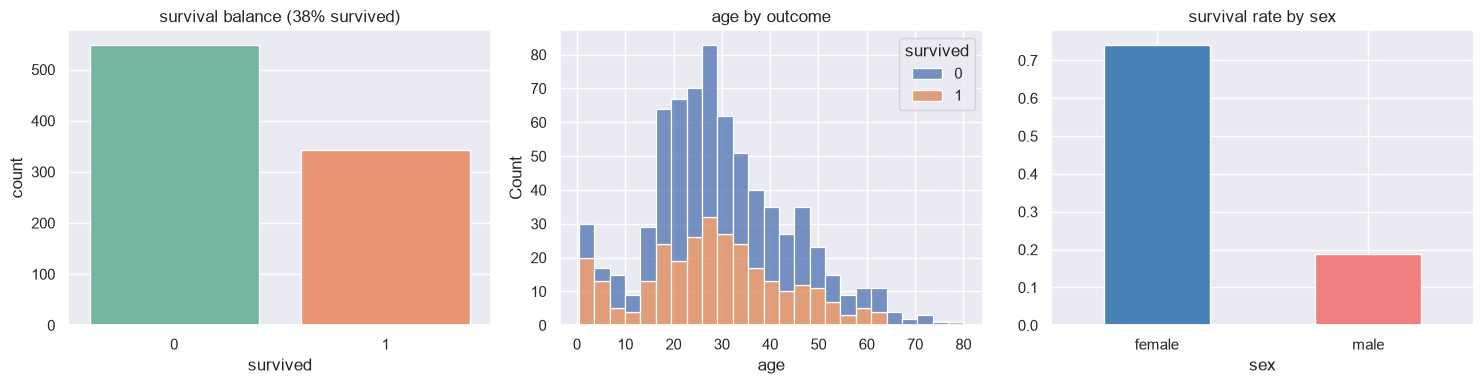

In [3]:
target_col = "survived"
print("missing values:\n", df[num_cols + cat_cols].isna().sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x=target_col, data=df, ax=axes[0],
              palette="Set2", hue=target_col, legend=False)
axes[0].set_title(f"survival balance ({df[target_col].mean():.0%} survived)")

sns.histplot(data=df, x="age", hue=target_col, bins=25,
             multiple="stack", ax=axes[1])
axes[1].set_title("age by outcome")

if "sex" in cat_cols:
    rate = df.groupby("sex")[target_col].mean()
    rate.plot(kind="bar", color=["steelblue", "lightcoral"], ax=axes[2])
    axes[2].set_title("survival rate by sex"); axes[2].tick_params(axis="x",
                                                                  rotation=0)
plt.tight_layout(); plt.show()

### 4. Data processing - impute → encode → split


In [4]:
work = df[num_cols + cat_cols + [target_col]].copy()

# median fill for age (robust), mode fill for any categorical gaps
for c in num_cols:
    if work[c].isna().any():
        work[c] = work[c].fillna(work[c].median())
for c in cat_cols:
    if work[c].isna().any():
        work[c] = work[c].fillna(work[c].mode()[0])

X = pd.get_dummies(work[cat_cols + num_cols], drop_first=True).values.astype(float)
y = work[target_col].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)
print("features after encoding:", X.shape[1])

features after encoding: 10


### 5. Model training - one line of Bayes


In [5]:
nb = GaussianNB().fit(X_tr, y_tr)
pred = nb.predict(X_te)

print(f"lazy all-die accuracy : {(y_te == 0).mean():.3f}")
print(f"GaussianNB accuracy   : {accuracy_score(y_te, pred):.4f}")
cv = cross_val_score(GaussianNB(), X_tr, y_tr, cv=5).mean()
print(f"5-fold CV             : {cv:.4f}")

display(pd.DataFrame(confusion_matrix(y_te, pred),
                     index=["true died", "true survived"],
                     columns=["pred died", "pred survived"]))

# peek inside: learned priors + per-class means of numeric features
print("\npriors:", dict(zip(["died", "survived"], nb.class_prior_.round(3))))
theta_tbl = pd.DataFrame(nb.theta_[:, :len(num_cols)],
                         columns=num_cols,
                         index=["died", "survived"]).T.round(2)
display(theta_tbl)

lazy all-die accuracy : 0.614
GaussianNB accuracy   : 0.7175
5-fold CV             : 0.7800


,pred died,pred survived
true died,108,29
true survived,34,52



priors: {'died': np.float64(0.617), 'survived': np.float64(0.383)}


,died,survived
pclass,2.55,1.94
age,30.37,28.23
sibsp,0.47,0.45
parch,0.31,0.49
fare,20.15,48.93


### 6. Findings

1. ~78-81% accuracy - NB matches heavier models here at ~50× less effort.
2. Priors anchor predictions at the true 62% death rate; per-class means show
     survivors were younger and wealthier.
3. Perfect auditability: every number above came straight from counting.

### Takeaway
Run GaussianNB first on ANY tabular problem - it sets the bar others must clear.